ML Assignment 4: Regression and Evaluation Metrics

ML Assignment 4: Regression and Evaluation Metrics

Objective

The objective of this assignment is to evaluate different regression
techniques in supervised learning by applying them to the California
Housing dataset and comparing their performance using different
evaluation metrics.

The regression algorithms implemented in this assignment are:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Support Vector Regressor (SVR)

The models are evaluated using:

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- R-squared Score (R²)

Cross-validation and hyperparameter tuning are also performed to
identify the most suitable regression model.

In [33]:
# Data manipulation
import pandas as pd
import numpy as np

In [34]:
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Dataset
from sklearn.datasets import fetch_california_housing

In [36]:
# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [37]:
# Regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

In [38]:
# Evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [39]:
# Cross-validation
from sklearn.model_selection import cross_val_score, KFold

In [40]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [41]:
import warnings
warnings.filterwarnings('ignore')

In [42]:
# Load California Housing dataset
housing = fetch_california_housing()

In [43]:
# Display dataset description
print(housing.DESCR[:2000])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [44]:
# Create DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [45]:
# Add target variable
df['MedHouseVal'] = housing.target

In [46]:
# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [47]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 9


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Dataset Information

The dataset contains information about houses and their surrounding
areas in California. The target variable is `MedHouseVal`, which
represents the median house value.

The remaining columns are used as independent variables to predict
the median house value.

In [49]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [50]:
# Check missing values
missing_values = df.isnull().sum()

In [51]:
print("Missing values in each column:")

Missing values in each column:


In [52]:
print(missing_values)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [53]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [54]:
df = df.dropna()

Missing Value Handling

The dataset was checked for missing values using `isnull().sum()`.

No missing values were found in the California Housing dataset.
Therefore, no imputation was necessary.

In [55]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [56]:
df = df.drop_duplicates()

In [57]:
# Independent variables
X = df.drop('MedHouseVal', axis=1)

In [58]:
# Dependent variable
y = df['MedHouseVal']

In [59]:
print("Features shape:", X.shape)

Features shape: (20640, 8)


In [60]:
print("Target shape:", y.shape)

Target shape: (20640,)


In [61]:
print("Feature names:")

Feature names:


In [62]:
print(X.columns.tolist())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


<Axes: xlabel='MedHouseVal', ylabel='Count'>

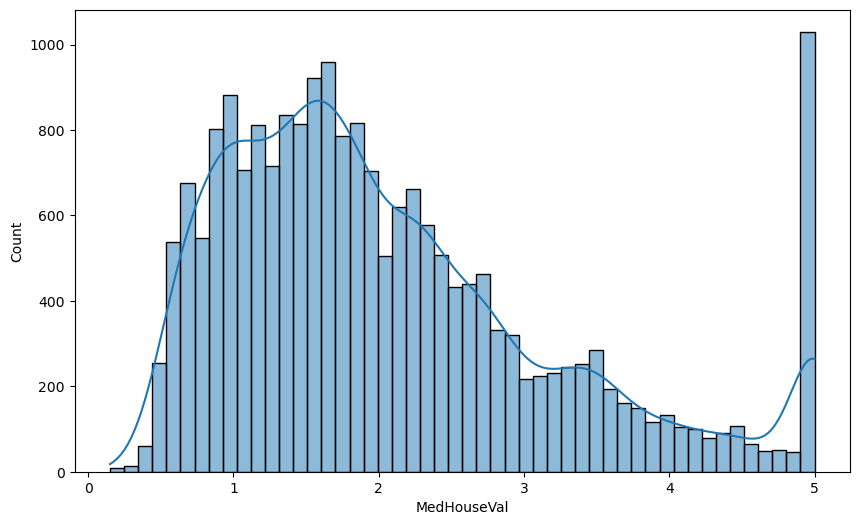

In [64]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['MedHouseVal'],
    bins=50,
    kde=True
)

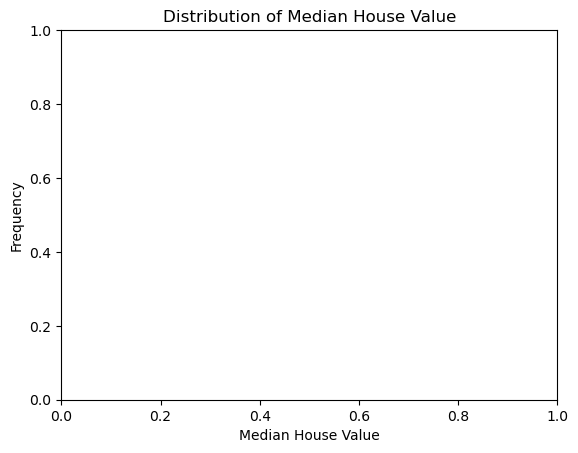

In [65]:
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

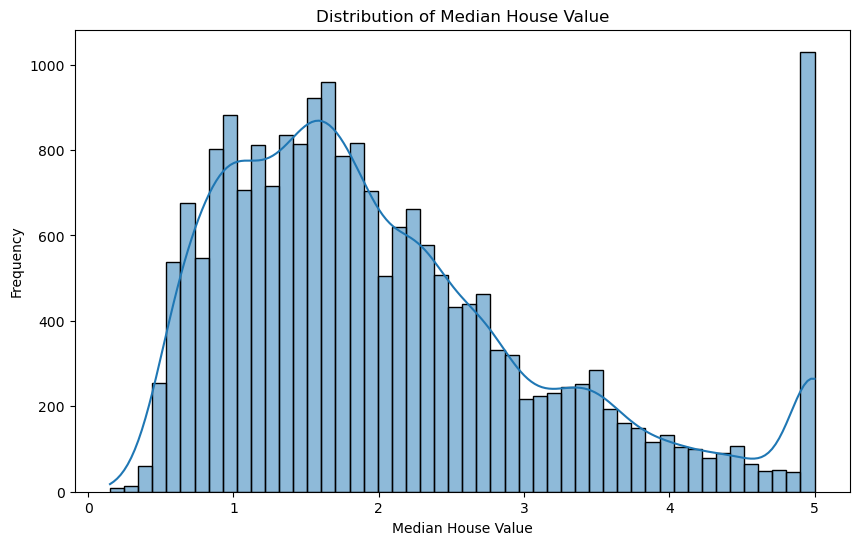

In [66]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['MedHouseVal'],
    bins=50,
    kde=True
)

plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows the distribution of the median house values.
The distribution provides an initial understanding of how house values
are spread across the dataset.

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

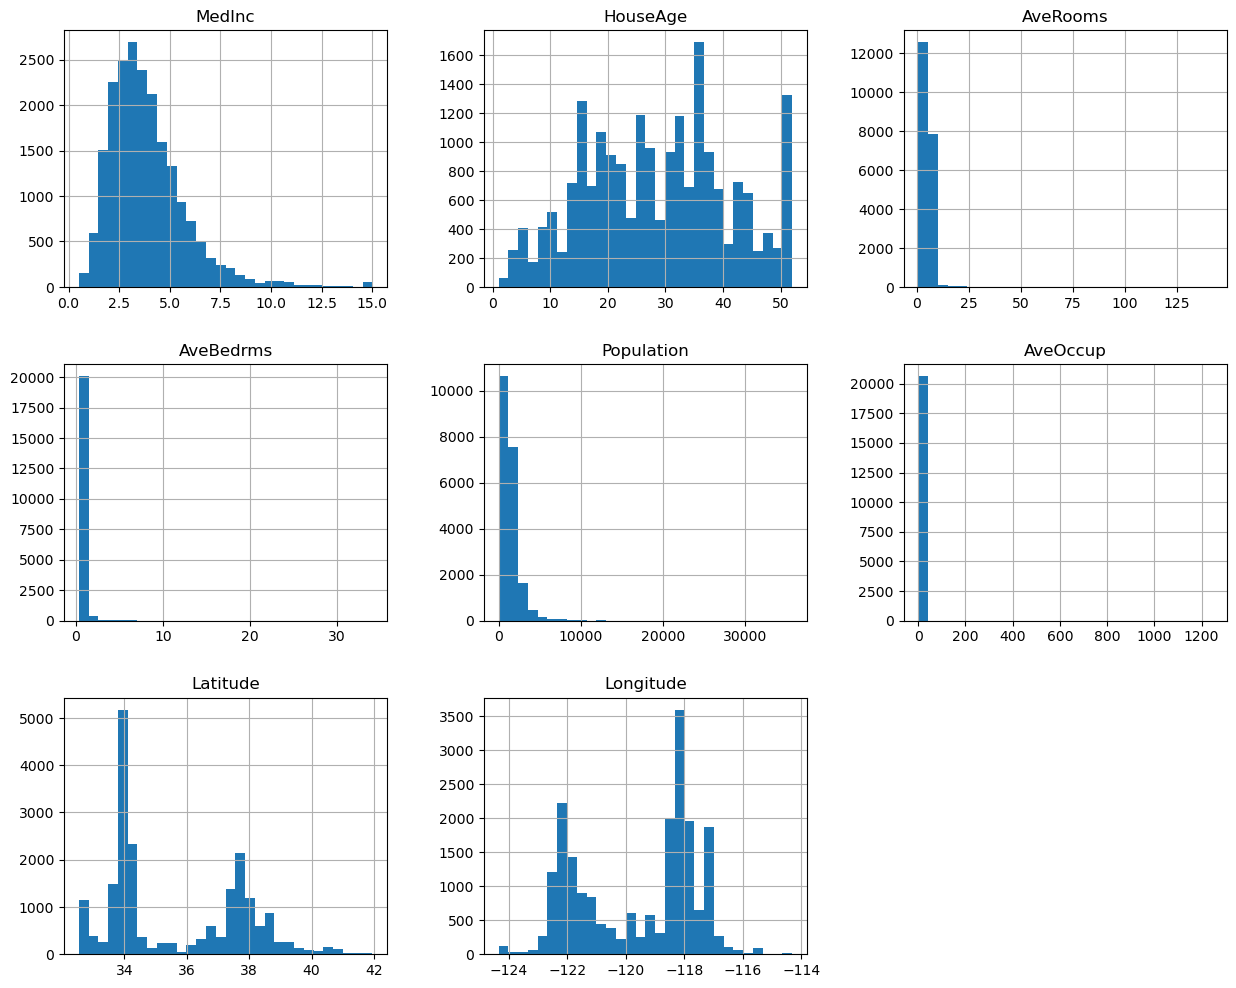

In [67]:
X.hist(
    figsize=(15, 12),
    bins=30
)

In [68]:
plt.suptitle('Distribution of Features', fontsize=16)

Text(0.5, 0.98, 'Distribution of Features')

<Figure size 640x480 with 0 Axes>

In [69]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### Feature Distribution Analysis

Histograms were plotted for all independent variables to understand
their distributions, ranges, and possible skewness.

Different features have different scales and distributions. Therefore,
feature scaling is useful, particularly for algorithms such as SVR.

In [70]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [71]:
correlation_matrix = df.corr()

<Axes: >

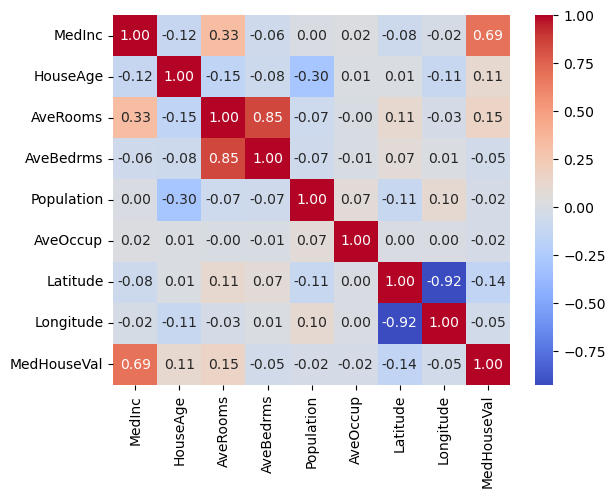

In [72]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

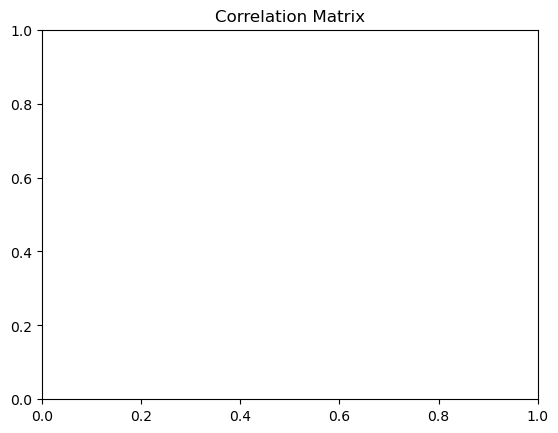

In [73]:
plt.title('Correlation Matrix')
plt.show()

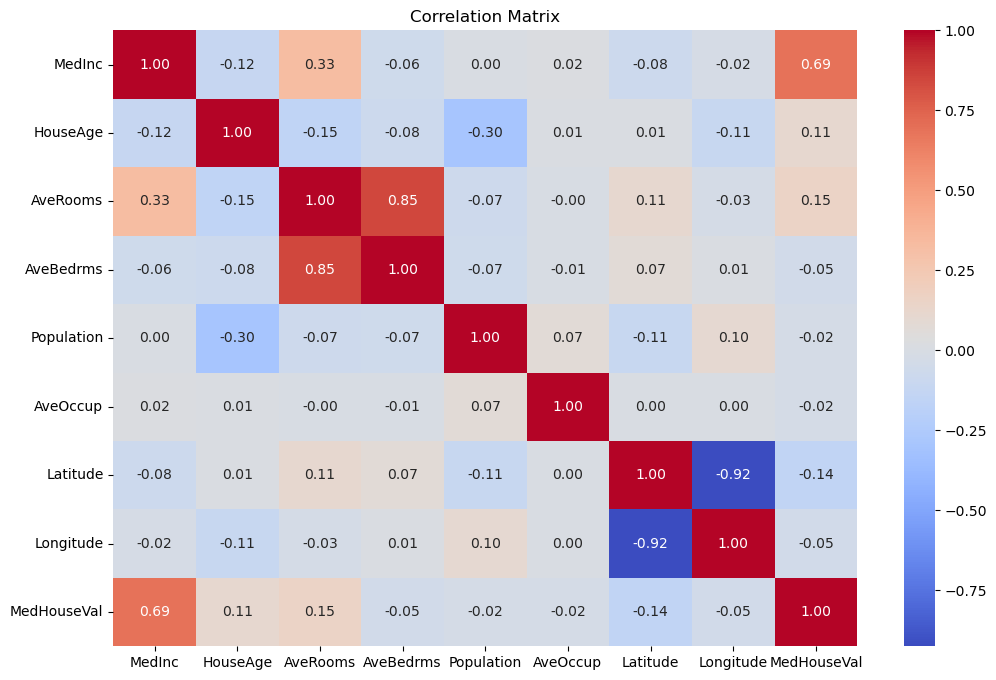

In [74]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [75]:
target_correlation = df.corr()['MedHouseVal'].sort_values(
    ascending=False
)

print(target_correlation)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


Correlation Analysis

The correlation matrix shows the relationship between the numerical
features and the target variable.

Correlation values closer to +1 indicate a strong positive linear
relationship, while values closer to -1 indicate a strong negative
linear relationship. Values close to 0 indicate a weak linear
relationship.

The correlation analysis helps provide an initial understanding of
which features may be useful for predicting median house values.

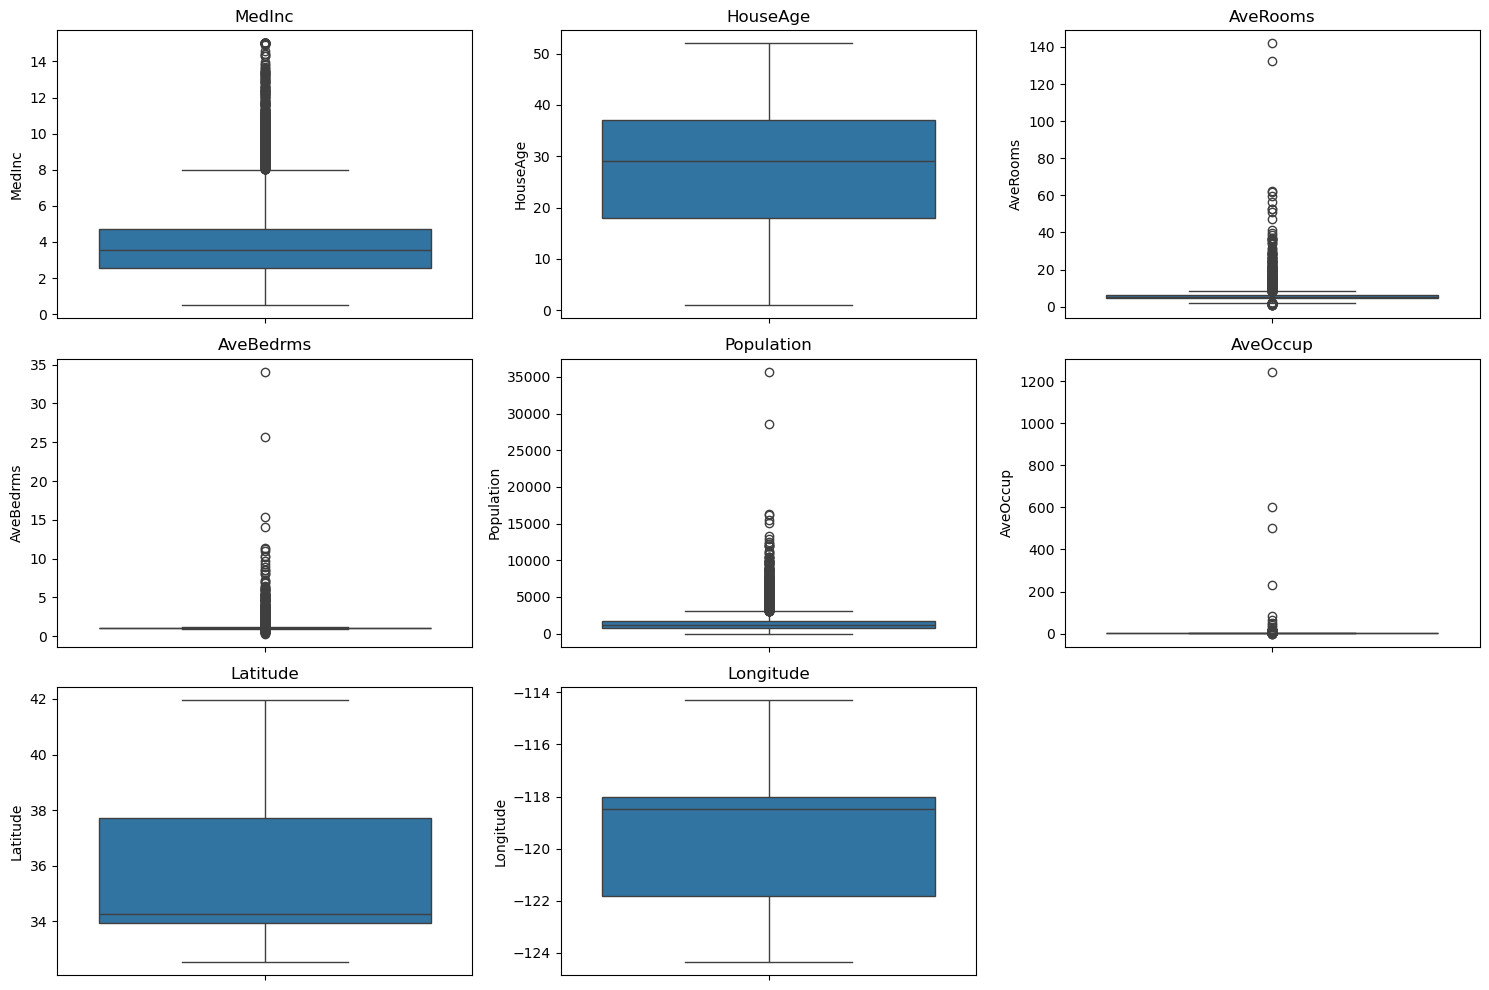

In [76]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(X.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=X[column])
    plt.title(column)

plt.tight_layout()

plt.show()

Outlier Analysis

Boxplots were used to identify the spread of the features and possible
outliers. Some variables contain observations that are far from their
central values.

These observations are retained because they may represent genuine
characteristics of different housing areas rather than data-entry
errors.

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [78]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)


In [79]:
# Create StandardScaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


 Feature Scaling

Standardization was used to scale the independent variables.

Standardization transforms the features so that they have approximately
a mean of 0 and a standard deviation of 1.

The scaler is fitted only on the training data and then applied to the
test data. This prevents information from the test set from influencing
the training process.

Feature scaling is particularly important for distance- and
margin-based algorithms such as Support Vector Regression (SVR).

In [80]:
# Initialize the regression models

linear_model = LinearRegression()

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

random_forest_model = RandomForestRegressor(
    random_state=42
)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

svr_model = SVR(
    kernel='rbf'
)

1. Linear Regression

Linear Regression is a supervised learning algorithm that models the
relationship between the dependent variable and one or more independent
variables by fitting a linear equation to the observed data.


In [81]:
# Train Linear Regression
linear_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
# Make predictions
linear_predictions = linear_model.predict(X_test_scaled)

In [83]:
print("Linear Regression predictions:")
print(linear_predictions[:10])

Linear Regression predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


2. Decision Tree Regressor

A Decision Tree Regressor predicts a continuous target variable by
splitting the dataset into smaller groups based on feature values.

In [84]:
# Train Decision Tree Regressor
decision_tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [85]:
# Make predictions
decision_tree_predictions = decision_tree_model.predict(X_test)

In [86]:
print("Decision Tree predictions:")
print(decision_tree_predictions[:10])

Decision Tree predictions:
[0.414   1.203   5.00001 2.17    2.257   1.787   2.217   1.74    2.772
 5.00001]


 3. Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines
multiple Decision Trees.

Each tree is trained using different samples and feature selections.
The predictions from the individual trees are combined to produce
the final prediction.

In [87]:
# Train Random Forest Regressor
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
# Make predictions
random_forest_predictions = random_forest_model.predict(X_test)

In [89]:
print("Random Forest predictions:")
print(random_forest_predictions[:10])

Random Forest predictions:
[0.5095    0.74161   4.9232571 2.52961   2.27369   1.64692   2.37605
 1.66932   2.7729706 4.9134589]


4. Gradient Boosting Regressor

Gradient Boosting is an ensemble technique that builds models
sequentially. Each new model attempts to reduce the errors made by
the previous models.

In [90]:
# Train Gradient Boosting Regressor
gradient_boosting_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [91]:
# Make predictions
gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

In [92]:
print("Gradient Boosting predictions:")
print(gradient_boosting_predictions[:10])

Gradient Boosting predictions:
[0.50518761 1.09334601 4.24570956 2.54517359 2.27910301 1.72390996
 2.33719663 1.71977379 3.09962388 4.30446906]


5. Support Vector Regressor (SVR)

Support Vector Regression is a regression technique based on Support
Vector Machines. SVR attempts to find a function that predicts the
target values while keeping the prediction errors within a specified
margin.

In [93]:
# Train Support Vector Regressor
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [94]:
# Make predictions
svr_predictions = svr_model.predict(X_test_scaled)

In [95]:
print("SVR predictions:")
print(svr_predictions[:10])

SVR predictions:
[0.51647228 1.56842925 3.59780295 2.49108208 2.56880838 1.67166034
 2.62538359 1.72918458 2.31909544 4.73053473]


In [96]:
def evaluate_model(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MSE': mse,
        'MAE': mae,
        'R² Score': r2
    }

In [97]:
results = []

results.append(
    evaluate_model(
        'Linear Regression',
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        decision_tree_predictions
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        random_forest_predictions
    )
)

results.append(
    evaluate_model(
        'Gradient Boosting',
        y_test,
        gradient_boosting_predictions
    )
)

results.append(
    evaluate_model(
        'SVR',
        y_test,
        svr_predictions
    )
)

In [98]:
results_df = pd.DataFrame(results)

results_df

,Model,MSE,MAE,R² Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


In [99]:
results_df.round(4)

,Model,MSE,MAE,R² Score
0,Linear Regression,0.5559,0.5332,0.5758
1,Decision Tree,0.4952,0.4547,0.6221
2,Random Forest,0.2554,0.3275,0.8051
3,Gradient Boosting,0.2940,0.3716,0.7756
4,SVR,0.3570,0.3986,0.7276


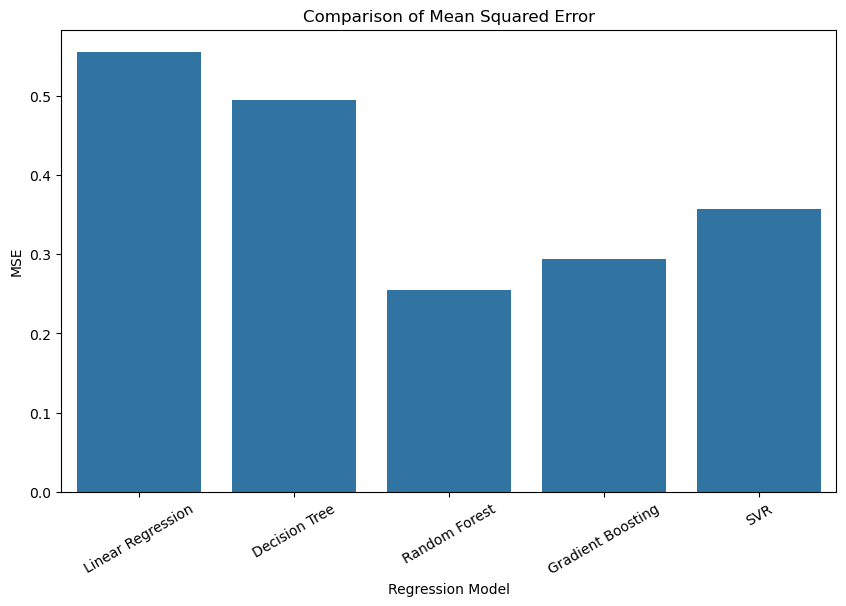

In [100]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='MSE'
)

plt.title('Comparison of Mean Squared Error')
plt.xlabel('Regression Model')
plt.ylabel('MSE')

plt.xticks(rotation=30)

plt.show()

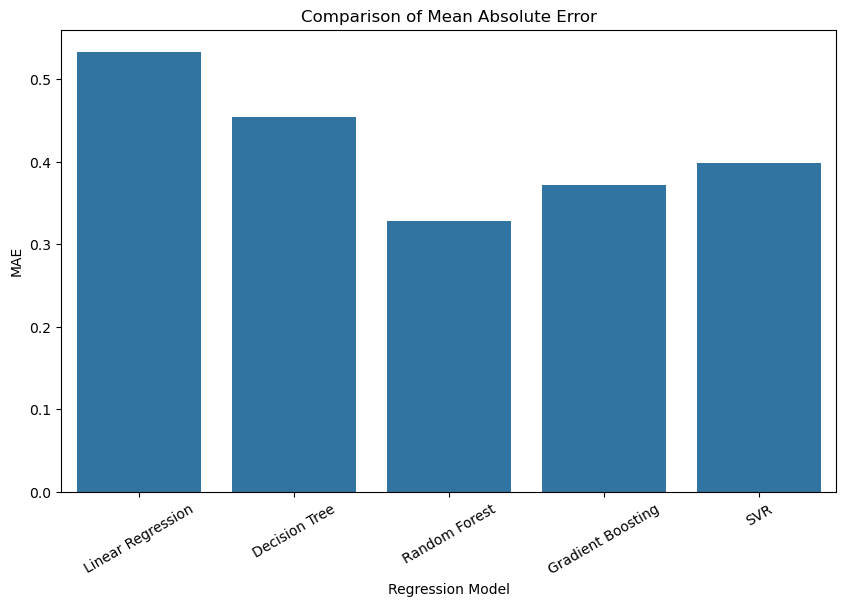

In [101]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='MAE'
)

plt.title('Comparison of Mean Absolute Error')
plt.xlabel('Regression Model')
plt.ylabel('MAE')

plt.xticks(rotation=30)

plt.show()

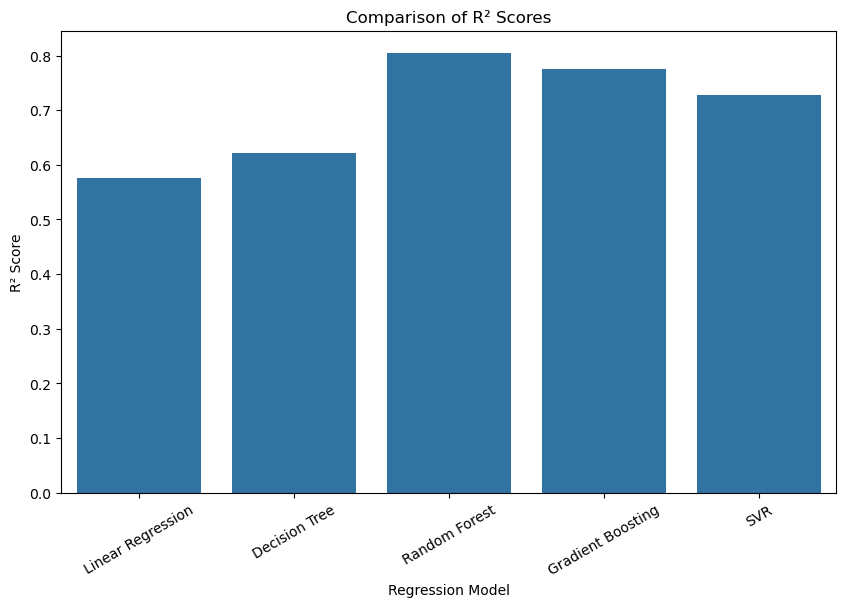

In [102]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R² Score'
)

plt.title('Comparison of R² Scores')
plt.xlabel('Regression Model')
plt.ylabel('R² Score')

plt.xticks(rotation=30)

plt.show()

In [103]:
best_r2_model = results_df.loc[
    results_df['R² Score'].idxmax()
]

In [104]:
print("Best model based on R² Score:")
print(best_r2_model)

Best model based on R² Score:
Model       Random Forest
MSE              0.255368
MAE              0.327543
R² Score         0.805123
Name: 2, dtype: object


In [105]:
best_mse_model = results_df.loc[
    results_df['MSE'].idxmin()
]

In [106]:
print("Best model based on MSE:")
print(best_mse_model)

Best model based on MSE:
Model       Random Forest
MSE              0.255368
MAE              0.327543
R² Score         0.805123
Name: 2, dtype: object


In [107]:
best_mae_model = results_df.loc[
    results_df['MAE'].idxmin()
]

In [108]:
print("Best model based on MAE:")
print(best_mae_model)

Best model based on MAE:
Model       Random Forest
MSE              0.255368
MAE              0.327543
R² Score         0.805123
Name: 2, dtype: object


In [109]:
worst_r2_model = results_df.loc[
    results_df['R² Score'].idxmin()
]

In [110]:
print("Model with the lowest R² Score:")
print(worst_r2_model)

Model with the lowest R² Score:
Model       Linear Regression
MSE                  0.555892
MAE                    0.5332
R² Score             0.575788
Name: 0, dtype: object


Initial Model Comparison

The five regression models were evaluated using Mean Squared Error
(MSE), Mean Absolute Error (MAE), and R-squared (R²).

For MSE and MAE, lower values indicate better predictive performance.
For R², a higher value indicates that the model explains a greater
proportion of the variation in the target variable.

The model comparison will be considered together with the results from
cross-validation and hyperparameter tuning before selecting the final
regression model.